In [1]:
import numpy as np
import pandas as pd
from scipy.stats import invwishart

# =========================
# 1. Cargar base
# =========================
url = "https://raw.githubusercontent.com/Andres1984/Data-Analysis-with-R/refs/heads/master/Bases/Smart_City_index.csv"
df = pd.read_csv(url)

# Limpiar nombres de columnas
df.columns = df.columns.str.strip()

# Variables del análisis
vars_cluster = [
    "Smart_Mobility",
    "Smart_Environment",
    "Smart_Government",
    "Smart_Economy",
    "Smart_People",
    "Smart_Living"
]

data = df[["City", "Country"] + vars_cluster].copy()

# Matriz de datos
X = data[vars_cluster].values
n, p = X.shape

print("Número de ciudades:", n)
print("Número de variables:", p)
print(data.head())

Número de ciudades: 102
Número de variables: 6
         City      Country  Smart_Mobility  Smart_Environment  \
0        Oslo       Norway            6480               6512   
1      Bergen       Norway            7097               6876   
2   Amsterdam  Netherlands            7540               5558   
3  Copenhagen      Denmark            7490               7920   
4   Stockholm       Sweden            6122               7692   

   Smart_Government  Smart_Economy  Smart_People  Smart_Living  
0              7516           4565          8618          9090  
1              7350           4905          8050          9090  
2              8528           8095          7098          7280  
3              8726           5580          5780          7200  
4              8354           4330          6743          7730  


In [2]:
# =========================
# 2. Hiperparámetros previos
# =========================

# Media previa para theta
mu0 = X.mean(axis=0)   # puedes cambiarla por otra creencia previa

# Fuerza de la prior sobre theta
kappa0 = 0.5           # pequeña => prior débil

# Grados de libertad previos para IW
nu0 = p + 2            # mínimo razonable para que exista la esperanza

# Escala previa de Sigma
# Usamos una versión diagonal basada en la varianza empírica
sample_vars = X.var(axis=0, ddof=1)
S0 = np.diag(sample_vars)

print("mu0 =", mu0)
print("kappa0 =", kappa0)
print("nu0 =", nu0)
print("S0 =\n", S0)

mu0 = [5759.40196078 5943.5        5893.80392157 6131.80392157 5874.04901961
 6377.03921569]
kappa0 = 0.5
nu0 = 8
S0 =
 [[1473869.17346146       0.               0.               0.
        0.               0.        ]
 [      0.         2972286.92574257       0.               0.
        0.               0.        ]
 [      0.               0.         1330274.57503397       0.
        0.               0.        ]
 [      0.               0.               0.         3245600.9512716
        0.               0.        ]
 [      0.               0.               0.               0.
  2099880.20549408       0.        ]
 [      0.               0.               0.               0.
        0.         5227613.42418948]]


In [3]:
# =========================
# 3. Estadísticos muestrales
# =========================
xbar = X.mean(axis=0)

# Matriz de dispersión:
# sum_i (x_i - xbar)(x_i - xbar)'
X_centered = X - xbar
Sn = X_centered.T @ X_centered

print("Media muestral:\n", xbar)
print("Matriz de dispersión Sn:\n", Sn)

Media muestral:
 [5759.40196078 5943.5        5893.80392157 6131.80392157 5874.04901961
 6377.03921569]
Matriz de dispersión Sn:
 [[ 1.48860787e+08 -4.65401815e+07 -6.80583196e+06 -5.79356630e+07
   6.16621290e+07  3.19712754e+07]
 [-4.65401815e+07  3.00200980e+08  5.74701280e+07  1.42564378e+08
  -7.67264350e+06  6.16360200e+07]
 [-6.80583196e+06  5.74701280e+07  1.34357732e+08  3.36234441e+07
   3.74894550e+07  1.17716407e+08]
 [-5.79356630e+07  1.42564378e+08  3.36234441e+07  3.27805696e+08
  -3.23044620e+07  1.92292908e+07]
 [ 6.16621290e+07 -7.67264350e+06  3.74894550e+07 -3.23044620e+07
   2.12087901e+08  1.07434561e+08]
 [ 3.19712754e+07  6.16360200e+07  1.17716407e+08  1.92292908e+07
   1.07434561e+08  5.27988956e+08]]


In [4]:
# =========================
# 4. Actualización posterior NIW
# =========================
kappa_n = kappa0 + n
nu_n = nu0 + n

mu_n = (kappa0 * mu0 + n * xbar) / kappa_n

diff = (xbar - mu0).reshape(-1, 1)
S_n = S0 + Sn + (kappa0 * n / kappa_n) * (diff @ diff.T)

print("kappa_n =", kappa_n)
print("nu_n =", nu_n)
print("mu_n =", mu_n)
print("S_n =\n", S_n)

kappa_n = 102.5
nu_n = 110
mu_n = [5759.40196078 5943.5        5893.80392157 6131.80392157 5874.04901961
 6377.03921569]
S_n =
 [[ 1.50334656e+08 -4.65401815e+07 -6.80583196e+06 -5.79356630e+07
   6.16621290e+07  3.19712754e+07]
 [-4.65401815e+07  3.03173266e+08  5.74701280e+07  1.42564378e+08
  -7.67264350e+06  6.16360200e+07]
 [-6.80583196e+06  5.74701280e+07  1.35688007e+08  3.36234441e+07
   3.74894550e+07  1.17716407e+08]
 [-5.79356630e+07  1.42564378e+08  3.36234441e+07  3.31051297e+08
  -3.23044620e+07  1.92292908e+07]
 [ 6.16621290e+07 -7.67264350e+06  3.74894550e+07 -3.23044620e+07
   2.14187781e+08  1.07434561e+08]
 [ 3.19712754e+07  6.16360200e+07  1.17716407e+08  1.92292908e+07
   1.07434561e+08  5.33216569e+08]]


In [5]:
# =========================
# 5. Simulación posterior
# =========================
n_draws = 5000

Sigma_draws = np.zeros((n_draws, p, p))
theta_draws = np.zeros((n_draws, p))

for s in range(n_draws):
    # 1) Simular Sigma desde Inverse-Wishart posterior
    Sigma_s = invwishart.rvs(df=nu_n, scale=S_n)
    Sigma_draws[s, :, :] = Sigma_s

    # 2) Simular theta | Sigma, X
    theta_s = np.random.multivariate_normal(mean=mu_n, cov=Sigma_s / kappa_n)
    theta_draws[s, :] = theta_s

theta_draws_df = pd.DataFrame(theta_draws, columns=vars_cluster)
print(theta_draws_df.head())

   Smart_Mobility  Smart_Environment  Smart_Government  Smart_Economy  \
0     5768.598894        5795.212847       5864.227329    6106.742255   
1     5715.571381        5953.511850       5799.557133    6082.164079   
2     5558.294371        6045.742265       5981.534304    6518.954334   
3     5855.936188        5911.622773       6125.170349    5953.963200   
4     5681.498895        5917.650285       5868.139559    6024.517197   

   Smart_People  Smart_Living  
0   5805.588941   6635.085856  
1   6083.879029   6448.308020  
2   5718.699418   6588.765614  
3   6066.407502   6767.576325  
4   5818.175267   6449.981884  


In [6]:
# =========================
# 6. Resumen posterior de theta
# =========================
summary_theta = pd.DataFrame({
    "media_posterior": theta_draws_df.mean(),
    "sd_posterior": theta_draws_df.std(),
    "q2.5": theta_draws_df.quantile(0.025),
    "q50": theta_draws_df.quantile(0.50),
    "q97.5": theta_draws_df.quantile(0.975)
})

print(summary_theta)

                   media_posterior  sd_posterior         q2.5          q50  \
Smart_Mobility         5757.508299    117.613684  5532.379736  5754.813117   
Smart_Environment      5945.636017    168.102245  5621.414921  5943.939948   
Smart_Government       5896.590118    112.589694  5672.782790  5896.300313   
Smart_Economy          6132.987135    174.326420  5785.418923  6133.019099   
Smart_People           5871.399919    143.262608  5593.577865  5873.444620   
Smart_Living           6377.353807    222.989641  5942.785263  6378.931993   

                         q97.5  
Smart_Mobility     5994.726844  
Smart_Environment  6264.907316  
Smart_Government   6115.788071  
Smart_Economy      6472.782476  
Smart_People       6156.104823  
Smart_Living       6803.619497  


In [7]:
# =========================
# 7. Media posterior de Sigma
# =========================
Sigma_post_mean = Sigma_draws.mean(axis=0)
Sigma_post_mean_df = pd.DataFrame(Sigma_post_mean, index=vars_cluster, columns=vars_cluster)

print("Media posterior de Sigma:")
print(Sigma_post_mean_df)

Media posterior de Sigma:
                   Smart_Mobility  Smart_Environment  Smart_Government  \
Smart_Mobility       1.456543e+06      -4.490534e+05     -6.699015e+04   
Smart_Environment   -4.490534e+05       2.944369e+06      5.598422e+05   
Smart_Government    -6.699015e+04       5.598422e+05      1.317877e+06   
Smart_Economy       -5.562240e+05       1.375438e+06      3.244519e+05   
Smart_People         5.949651e+05      -7.175832e+04      3.636558e+05   
Smart_Living         3.088318e+05       6.058106e+05      1.141788e+06   

                   Smart_Economy  Smart_People  Smart_Living  
Smart_Mobility     -5.562240e+05  5.949651e+05  3.088318e+05  
Smart_Environment   1.375438e+06 -7.175832e+04  6.058106e+05  
Smart_Government    3.244519e+05  3.636558e+05  1.141788e+06  
Smart_Economy       3.203950e+06 -3.108162e+05  1.888002e+05  
Smart_People       -3.108162e+05  2.079284e+06  1.040411e+06  
Smart_Living        1.888002e+05  1.040411e+06  5.168623e+06  


In [8]:
# =========================
# 8. Correlación posterior promedio
# =========================
corr_draws = np.zeros((n_draws, p, p))

for s in range(n_draws):
    D = np.sqrt(np.diag(Sigma_draws[s]))
    corr_draws[s] = Sigma_draws[s] / np.outer(D, D)

corr_post_mean = corr_draws.mean(axis=0)
corr_post_mean_df = pd.DataFrame(corr_post_mean, index=vars_cluster, columns=vars_cluster)

print("Correlación posterior promedio:")
print(corr_post_mean_df)

Correlación posterior promedio:
                   Smart_Mobility  Smart_Environment  Smart_Government  \
Smart_Mobility           1.000000          -0.215953         -0.048174   
Smart_Environment       -0.215953           1.000000          0.282870   
Smart_Government        -0.048174           0.282870          1.000000   
Smart_Economy           -0.256244           0.446150          0.156994   
Smart_People             0.340503          -0.029048          0.218706   
Smart_Living             0.112047           0.154478          0.435968   

                   Smart_Economy  Smart_People  Smart_Living  
Smart_Mobility         -0.256244      0.340503      0.112047  
Smart_Environment       0.446150     -0.029048      0.154478  
Smart_Government        0.156994      0.218706      0.435968  
Smart_Economy           1.000000     -0.120108      0.046102  
Smart_People           -0.120108      1.000000      0.315933  
Smart_Living            0.046102      0.315933      1.000000  


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import invwishart, gaussian_kde
import seaborn as sns

# ======================================================
# 1. Cargar datos
# ======================================================
url = "https://raw.githubusercontent.com/Andres1984/Data-Analysis-with-R/refs/heads/master/Bases/Smart_City_index.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()

vars_cluster = [
    "Smart_Mobility",
    "Smart_Environment",
    "Smart_Government",
    "Smart_Economy",
    "Smart_People",
    "Smart_Living"
]

data = df[["City", "Country"] + vars_cluster].copy()
X = data[vars_cluster].dropna().values
n, p = X.shape

# ======================================================
# 2. Hiperparámetros previos NIW
# ======================================================
mu0 = X.mean(axis=0) - 5   # mover ligeramente la prior para que se vea el cambio
kappa0 = 0.5
nu0 = p + 5

sample_vars = X.var(axis=0, ddof=1)
S0 = np.diag(sample_vars * 1.5)

# ======================================================
# 3. Estadísticos muestrales
# ======================================================
xbar = X.mean(axis=0)
X_centered = X - xbar
Sn = X_centered.T @ X_centered

# ======================================================
# 4. Parámetros posteriores NIW
# ======================================================
kappa_n = kappa0 + n
nu_n = nu0 + n
mu_n = (kappa0 * mu0 + n * xbar) / kappa_n

diff = (xbar - mu0).reshape(-1, 1)
S_n = S0 + Sn + (kappa0 * n / kappa_n) * (diff @ diff.T)

# ======================================================
# 5. Simulación previa y posterior
# ======================================================
n_draws = 5000

Sigma_prior_draws = np.zeros((n_draws, p, p))
theta_prior_draws = np.zeros((n_draws, p))

Sigma_post_draws = np.zeros((n_draws, p, p))
theta_post_draws = np.zeros((n_draws, p))

for s in range(n_draws):
    # Prior
    Sigma0_s = invwishart.rvs(df=nu0, scale=S0)
    theta0_s = np.random.multivariate_normal(mean=mu0, cov=Sigma0_s / kappa0)

    Sigma_prior_draws[s] = Sigma0_s
    theta_prior_draws[s] = theta0_s

    # Posterior
    Sigma_s = invwishart.rvs(df=nu_n, scale=S_n)
    theta_s = np.random.multivariate_normal(mean=mu_n, cov=Sigma_s / kappa_n)

    Sigma_post_draws[s] = Sigma_s
    theta_post_draws[s] = theta_s

theta_prior_df = pd.DataFrame(theta_prior_draws, columns=vars_cluster)
theta_post_df  = pd.DataFrame(theta_post_draws, columns=vars_cluster)



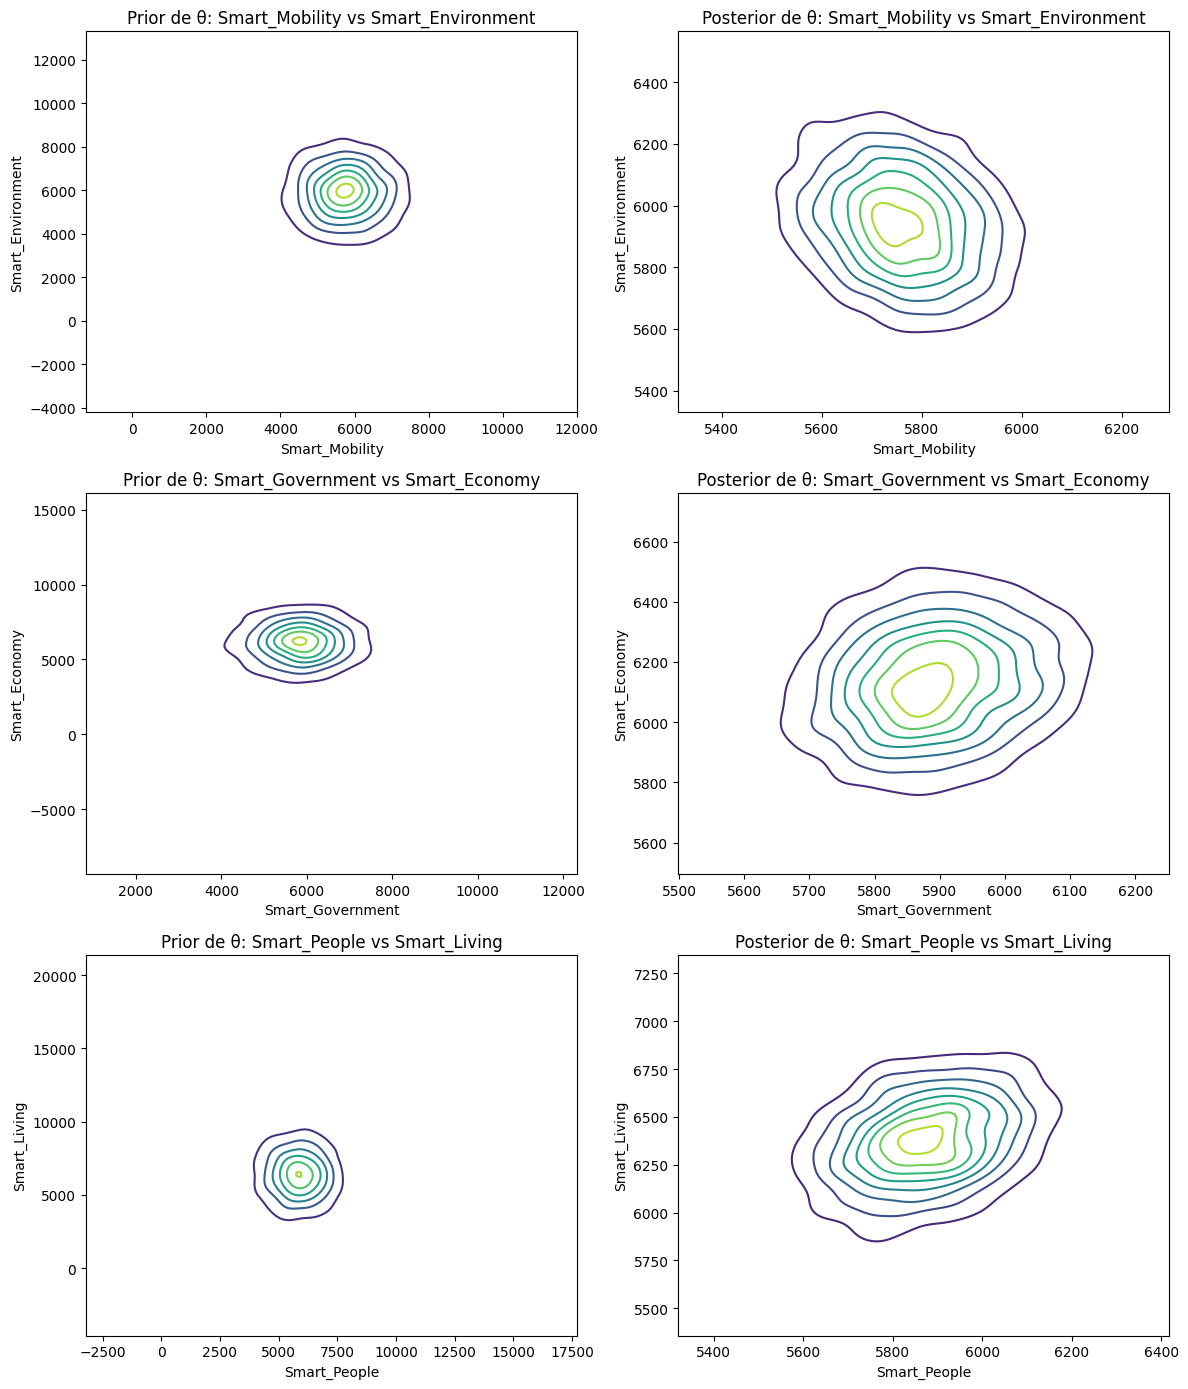

In [11]:
# ======================================================
# 6. Función para contornos 2D
# ======================================================
def contour_from_samples(ax, x, y, levels=8, title="", xlabel="", ylabel=""):
    values = np.vstack([x, y])
    kde = gaussian_kde(values)

    xgrid = np.linspace(np.min(x), np.max(x), 120)
    ygrid = np.linspace(np.min(y), np.max(y), 120)
    Xg, Yg = np.meshgrid(xgrid, ygrid)
    Z = kde(np.vstack([Xg.ravel(), Yg.ravel()])).reshape(Xg.shape)

    ax.contour(Xg, Yg, Z, levels=levels)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

# ======================================================
# 7. Gráficos de contorno de theta: prior vs posterior
# ======================================================
pairs = [
    ("Smart_Mobility", "Smart_Environment"),
    ("Smart_Government", "Smart_Economy"),
    ("Smart_People", "Smart_Living")
]

fig, axes = plt.subplots(len(pairs), 2, figsize=(12, 14))

for i, (v1, v2) in enumerate(pairs):
    contour_from_samples(
        axes[i, 0],
        theta_prior_df[v1],
        theta_prior_df[v2],
        title=f"Prior de θ: {v1} vs {v2}",
        xlabel=v1,
        ylabel=v2
    )

    contour_from_samples(
        axes[i, 1],
        theta_post_df[v1],
        theta_post_df[v2],
        title=f"Posterior de θ: {v1} vs {v2}",
        xlabel=v1,
        ylabel=v2
    )

plt.tight_layout()
plt.show()



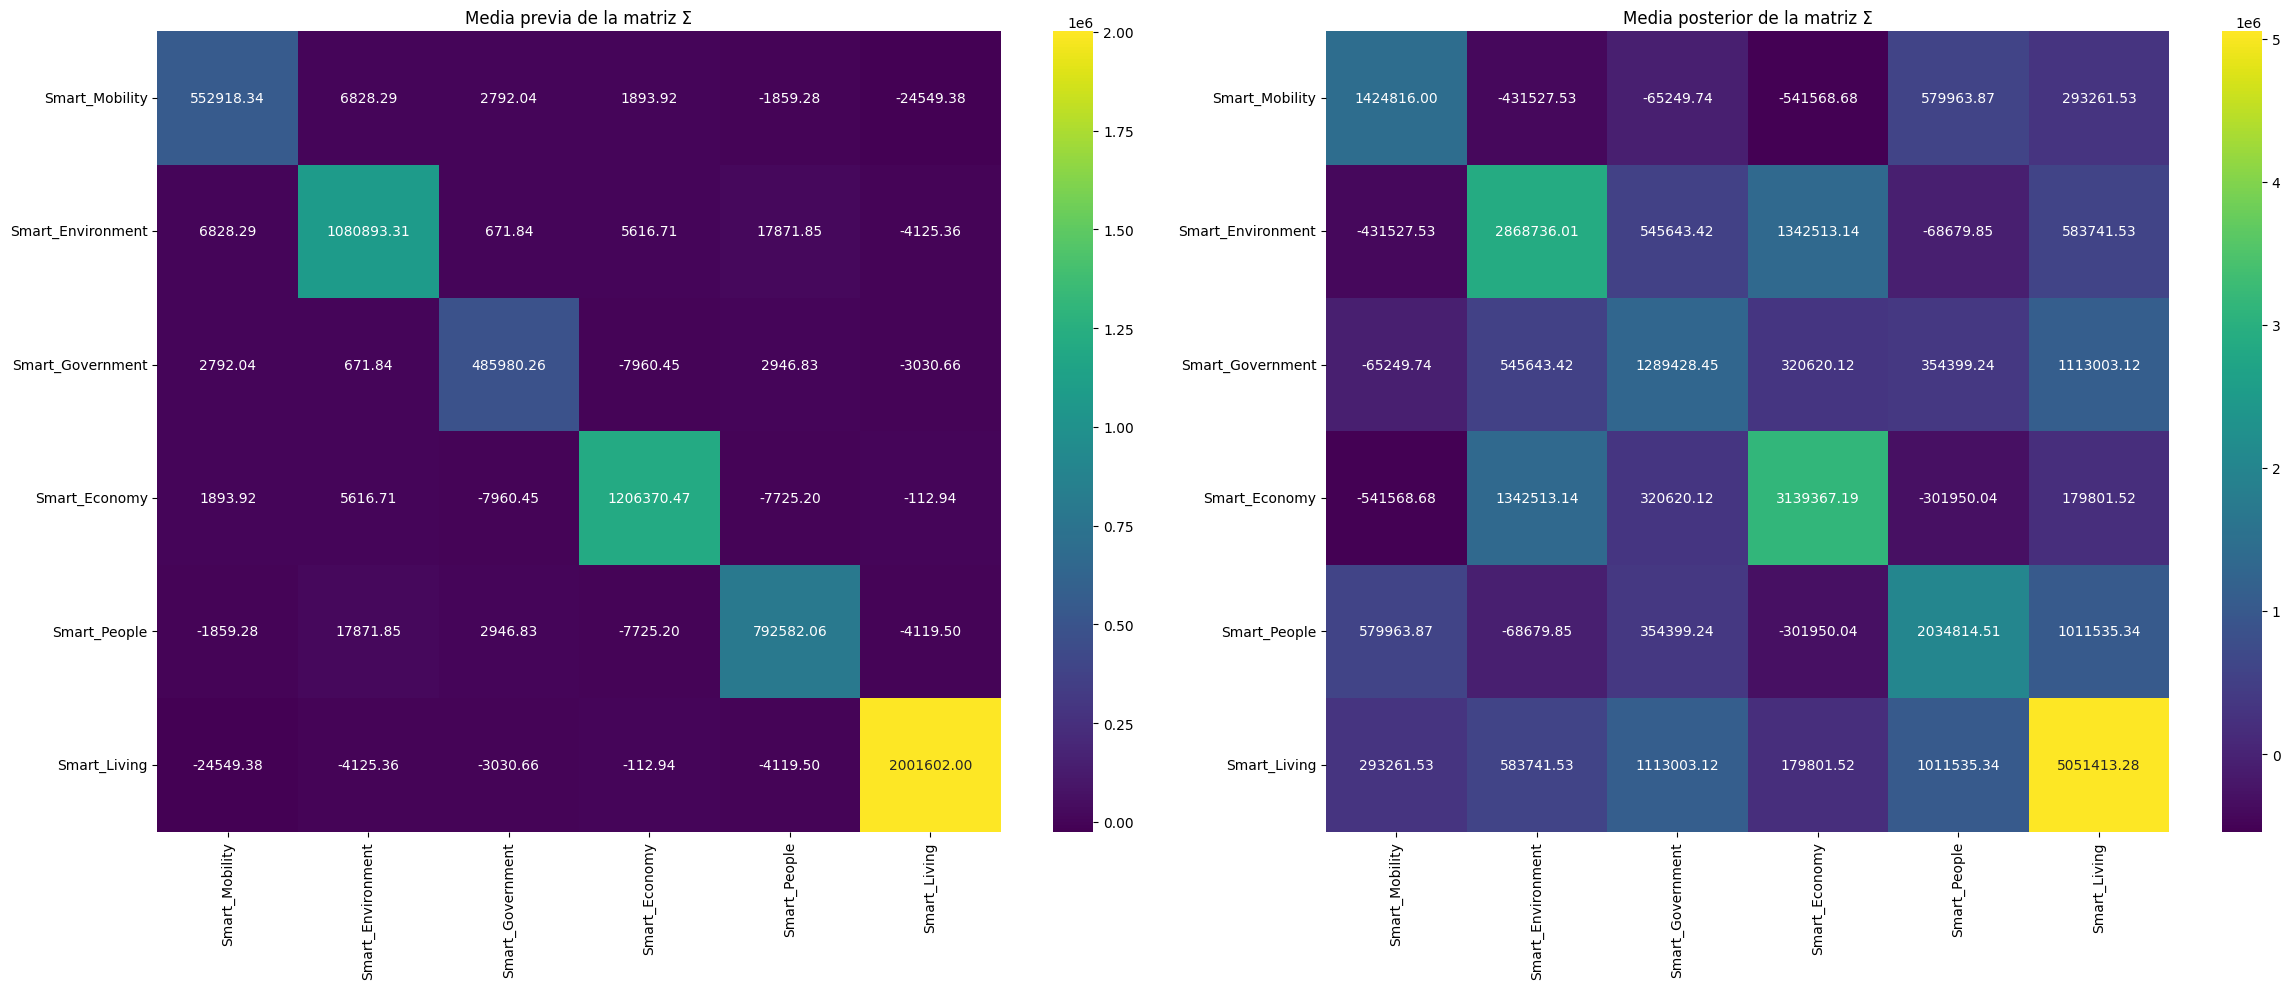

In [21]:
# ======================================================
# 8. Media previa y posterior de Sigma
# ======================================================
Sigma_prior_mean = Sigma_prior_draws.mean(axis=0)
Sigma_post_mean  = Sigma_post_draws.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

sns.heatmap(
    Sigma_prior_mean,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    xticklabels=vars_cluster,
    yticklabels=vars_cluster,
    ax=axes[0]
)
axes[0].set_title("Media previa de la matriz Σ")

sns.heatmap(
    Sigma_post_mean,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    xticklabels=vars_cluster,
    yticklabels=vars_cluster,
    ax=axes[1]
)
axes[1].set_title("Media posterior de la matriz Σ")

plt.tight_layout()
plt.show()


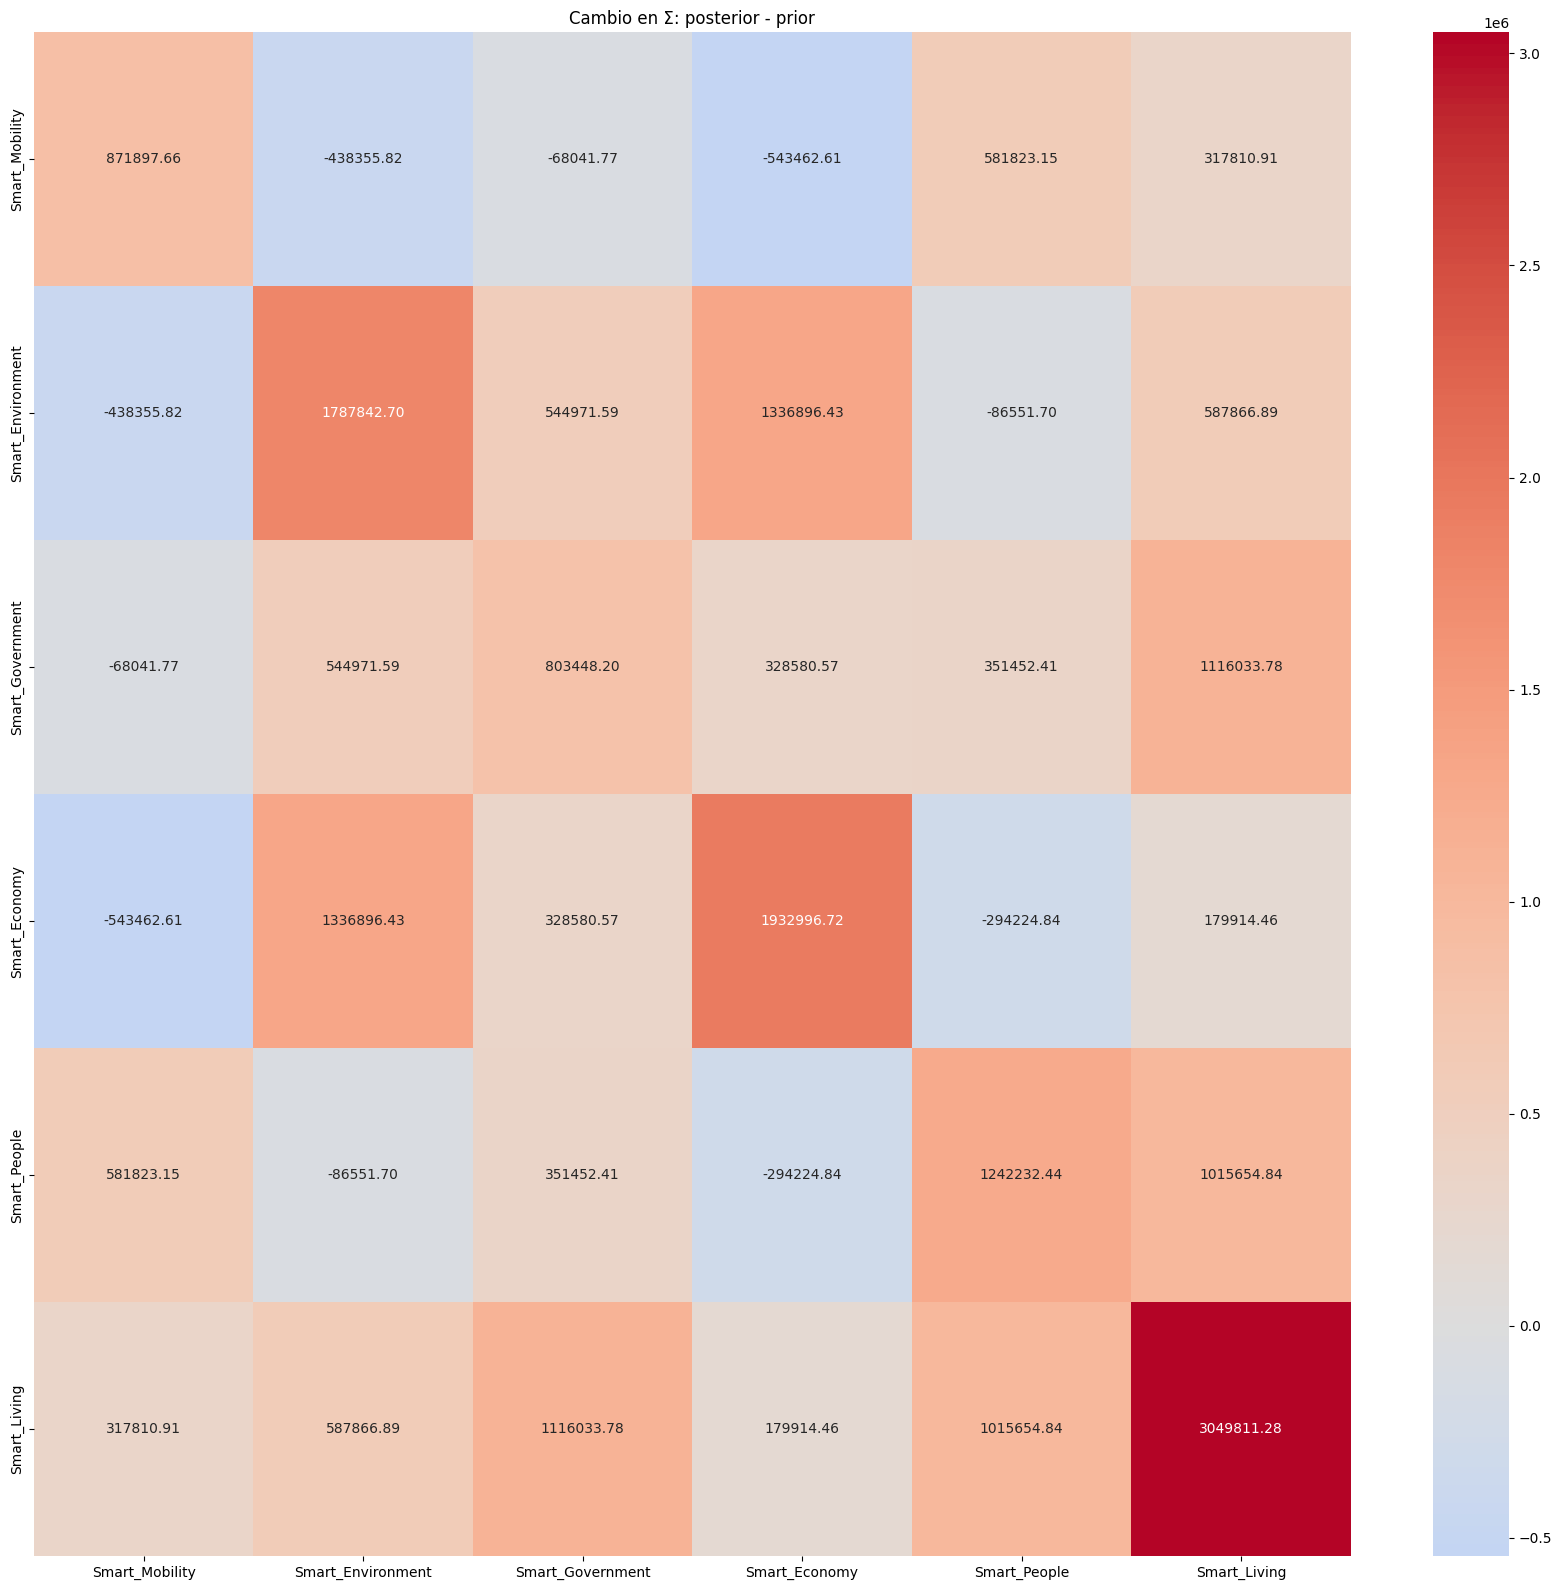

In [19]:
# ======================================================
# 9. Cambio entre matriz posterior y previa
# ======================================================
Sigma_diff = Sigma_post_mean - Sigma_prior_mean

plt.figure(figsize=(17, 16))
sns.heatmap(
    Sigma_diff,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    xticklabels=vars_cluster,
    yticklabels=vars_cluster
)
plt.title("Cambio en Σ: posterior - prior")
plt.tight_layout()
plt.show()



In [24]:
# ======================================================
# 11. Intervalos posteriores resumidos
# ======================================================
summary_theta = pd.DataFrame({
    "Prior_mean": theta_prior_df.mean(),
    "Post_mean": theta_post_df.mean(),
    "Post_q2.5": theta_post_df.quantile(0.025),
    "Post_q97.5": theta_post_df.quantile(0.975)
})

print("\nResumen de theta:")
print(summary_theta.round(3))

Sigma_prior_mean_df = pd.DataFrame(Sigma_prior_mean, index=vars_cluster, columns=vars_cluster)
Sigma_post_mean_df = pd.DataFrame(Sigma_post_mean, index=vars_cluster, columns=vars_cluster)

print("\nMedia previa de Sigma:")
print(Sigma_prior_mean_df.round(3))

print("\nMedia posterior de Sigma:")
print(Sigma_post_mean_df.round(3))


Resumen de theta:
                   Prior_mean  Post_mean  Post_q2.5  Post_q97.5
Smart_Mobility       5763.165   5759.080   5528.709    5990.323
Smart_Environment    5907.533   5941.463   5607.375    6267.780
Smart_Government     5868.249   5891.658   5677.845    6111.673
Smart_Economy        6128.734   6132.813   5788.877    6486.023
Smart_People         5881.326   5872.650   5601.004    6148.215
Smart_Living         6341.230   6375.870   5931.543    6808.031

Media previa de Sigma:
                   Smart_Mobility  Smart_Environment  Smart_Government  \
Smart_Mobility         552918.338           6828.289          2792.039   
Smart_Environment        6828.289        1080893.309           671.836   
Smart_Government         2792.039            671.836        485980.257   
Smart_Economy            1893.923           5616.706         -7960.447   
Smart_People            -1859.279          17871.847          2946.830   
Smart_Living           -24549.379          -4125.365         -303